In [12]:
%matplotlib inline
from __future__ import division
import numpy as np
from numpy.random import rand
import matplotlib.pyplot as plt
from numba import jit
import os
from tqdm import tqdm

## Honeycomb Lattice Ising Model

**Hamiltonian:** $H = -J \sum_{\langle i,j \rangle} s_i s_j$ where spins $s_i \in \{-1, +1\}$ and the sum is over the **3 nearest neighbours** of the honeycomb lattice.

### Why this is different from the triangular ("hexagonal") model

The existing `IsingModelHexagonal` notebooks implement the **triangular** lattice (z = 6 neighbours, 1 site per unit cell).  
The **honeycomb** lattice has z = 3 neighbours and **2 sites per unit cell** (sublattices A and B), requiring a `(2, N, N)` data structure.

| Property | Triangular | Honeycomb |
|---|---|---|
| z (coordination) | 6 | 3 |
| Bipartite? | No | **Yes** |
| Frustrated AFM? | Yes | **No** — AFM orders at finite T |
| Exact $T_c$ (ferro) | $4J/\ln 3 \approx 3.641$ | $2J/\ln(2+\sqrt{3}) \approx 1.519$ |

### Two-sublattice representation

We index unit cells by $(i, j)$ with $i, j \in \{0,\ldots,N{-}1\}$, giving $2N^2$ spins total.

| Sublattice | Index | 3 Neighbours |
|---|---|---|
| A | `spins[0, i, j]` | B$(i,j)$, B$(i-1,j)$, B$(i,j-1)$ |
| B | `spins[1, i, j]` | A$(i,j)$, A$(i+1,j)$, A$(i,j+1)$ |

All indices are mod $N$ (periodic boundary conditions).

### Physical site positions (bond length = 1)

Primitive vectors: $\mathbf{a}_1 = (\sqrt{3},\,0)$, $\mathbf{a}_2 = (\tfrac{\sqrt{3}}{2},\,\tfrac{3}{2})$.

$$\mathbf{r}_A(i,j) = j\,\mathbf{a}_1 + i\,\mathbf{a}_2 = \bigl(j\sqrt{3}+\tfrac{i\sqrt{3}}{2},\;\tfrac{3i}{2}\bigr)$$
$$\mathbf{r}_B(i,j) = \mathbf{r}_A(i,j) + \bigl(\tfrac{\sqrt{3}}{2},\,\tfrac{1}{2}\bigr)$$

Each A site has 3 bonds of length 1 pointing to its three B neighbours.

### Staggered magnetisation (AFM order parameter)
Because the honeycomb is bipartite, the antiferromagnet has a true ordered phase. Its order parameter is:
$$M_{\rm stag} = \frac{\sum_A s_i - \sum_B s_j}{2N^2}$$
which is $\pm 1$ in the perfectly ordered Néel state and 0 in the disordered phase.

In [1]:
#----------------------------------------------------------------------
##  BLOCK OF FUNCTIONS USED IN THE MAIN CODE
#----------------------------------------------------------------------

def initialstate(N):
    '''
    Random spin configuration on the honeycomb lattice.
    Returns shape (2, N, N): axis-0 is sublattice (0=A, 1=B),
    axes 1-2 are unit-cell indices (i, j).
    '''
    return 2 * np.random.randint(2, size=(2, N, N)) - 1


@jit(nopython=True)
def mcmove(spins, beta, J, N):
    '''
    One full MC sweep (2*N*N single-spin Metropolis trials).

    At each trial a sublattice (0=A or 1=B) and unit cell (i,j) are
    chosen at random.  The energy change from flipping that spin is
    computed from its 3 honeycomb neighbours and the Metropolis criterion
    is applied.

    Neighbour convention (all indices mod N):
      A(i,j) -> B(i,j),  B(i-1,j),  B(i,j-1)
      B(i,j) -> A(i,j),  A(i+1,j),  A(i,j+1)
    '''
    for _ in range(2 * N * N):
        sub = np.random.randint(0, 2)   # 0 = A sublattice, 1 = B sublattice
        i   = np.random.randint(0, N)
        j   = np.random.randint(0, N)
        s   = spins[sub, i, j]

        if sub == 0:   # A site: 3 neighbours are B(i,j), B(i-1,j), B(i,j-1)
            nb = (spins[1,  i,          j          ]
                + spins[1, (i - 1) % N, j          ]
                + spins[1,  i,         (j - 1) % N])
        else:          # B site: 3 neighbours are A(i,j), A(i+1,j), A(i,j+1)
            nb = (spins[0,  i,          j          ]
                + spins[0, (i + 1) % N, j          ]
                + spins[0,  i,         (j + 1) % N])

        cost = 2 * J * s * nb
        if cost < 0:
            s *= -1
        elif rand() < np.exp(-cost * beta):
            s *= -1
        spins[sub, i, j] = s
    return spins


@jit(nopython=True)
def calcEnergy(spins, J, N):
    '''
    Total energy of the configuration.

    Iterates over A sites only, counting all 3 A-B bonds per site.
    Since A and B are distinct sublattices, each bond is counted once:
        3 bonds/unit cell * N^2 unit cells = 3N^2 bonds  (= z*2N^2/2 = 3N^2) ✓
    '''
    energy = 0
    for i in range(N):
        for j in range(N):
            S_A = spins[0, i, j]
            energy += -J * S_A * (spins[1,  i,          j          ]   # B(i,j)
                                + spins[1, (i - 1) % N, j          ]   # B(i-1,j)
                                + spins[1,  i,         (j - 1) % N])   # B(i,j-1)
    return energy


@jit(nopython=True)
def calcMag(spins):
    '''Total magnetisation (sum of all spins on both sublattices).'''
    return np.sum(spins[0]) + np.sum(spins[1])


@jit(nopython=True)
def calcStagMag(spins):
    '''
    Staggered magnetisation — the order parameter for the
    antiferromagnetic Neel state on the honeycomb lattice.

    M_stag = (sum_A s - sum_B s) / (2 N^2)

    = +/-1 in the fully ordered Neel state
    =  0   in the disordered (high-T) phase

    The honeycomb is bipartite, so unlike the frustrated triangular
    AFM, this quantity undergoes a true second-order transition.
    '''
    return np.sum(spins[0]) - np.sum(spins[1])

NameError: name 'jit' is not defined

In [ ]:
#----------------------------------------------------------------------
##  VISUALIZATION AND I/O HELPERS
#----------------------------------------------------------------------

def makeFigSaveData(spins, N, beta, folder):
    '''
    Save the spin configuration and a pcolormesh figure.

    The (2, N, N) spin array is reshaped to (2N, N) for storage:
    the top N rows are sublattice A, the bottom N rows are sublattice B.
    To reload: spins = np.loadtxt(fname).reshape(2, N, N)
    '''
    flat = spins.reshape(2 * N, N)   # (2N, N): A on top, B on bottom

    X, Y = np.meshgrid(range(N), range(2 * N))
    plt.figure()
    plt.pcolormesh(X, Y, flat, cmap=plt.cm.binary)
    a = plt.gca()
    a.axes.get_xaxis().set_visible(False)
    a.axes.get_yaxis().set_visible(False)
    plt.axis('tight')

    fname = 'beta_' + str(beta) + '_'
    fig_dir = 'figures/' + folder
    if not os.path.isdir(fig_dir):
        os.makedirs(fig_dir)
    plt.savefig('./' + fig_dir + '/' + fname + '.png')
    np.savetxt('./' + folder + '/' + fname + '.txt', flat)
    plt.close()


def _honeycomb_positions(N):
    '''
    Compute physical (x, y) positions for all A and B sites.

    Primitive vectors: a1=(sqrt(3),0), a2=(sqrt(3)/2, 3/2).
    Basis offsets:
      A(i,j) at  j*a1 + i*a2
      B(i,j) at  j*a1 + i*a2 + (sqrt(3)/2, 1/2)

    All three A-B bonds have length 1 (verified analytically).
    '''
    xs_A, ys_A = [], []
    xs_B, ys_B = [], []
    sqrt3 = np.sqrt(3)
    for i in range(N):
        for j in range(N):
            xa = j * sqrt3 + i * sqrt3 / 2
            ya = i * 1.5
            xs_A.append(xa)
            ys_A.append(ya)
            xs_B.append(xa + sqrt3 / 2)
            ys_B.append(ya + 0.5)
    return (np.array(xs_A), np.array(ys_A),
            np.array(xs_B), np.array(ys_B))


def plotHoneycomb(spins, N, T, title='', draw_bonds=True, folder=None):
    '''
    Render spins at their true honeycomb-lattice positions.

    A sites (circles) and B sites (diamonds) are coloured by spin.
    The three bond types are drawn in light gray for orientation.
    Bonds that wrap around the periodic boundary are omitted so the
    finite simulation box looks clean.
    '''
    xs_A, ys_A, xs_B, ys_B = _honeycomb_positions(N)
    spins_A = spins[0].ravel()
    spins_B = spins[1].ravel()
    sqrt3 = np.sqrt(3)

    # Physical box extents (for clipping wrap-around bonds)
    x_max = (N - 1) * sqrt3 + (N - 1) * sqrt3 / 2 + sqrt3 + 1
    y_max = (N - 1) * 1.5 + 1 + 0.5 + 1

    fig, ax = plt.subplots(figsize=(min(12, N * 1.2 + 2), min(10, N * 1.0 + 2)))

    # --- Draw bonds first (so spins sit on top) ---
    if draw_bonds:
        idx = 0
        for i in range(N):
            for j in range(N):
                xa, ya = xs_A[idx], ys_A[idx]
                # Bond 1: A(i,j) -- B(i,j)   direction (sqrt3/2, 1/2)
                xb0, yb0 = xs_B[idx], ys_B[idx]
                # Bond 2: A(i,j) -- B(i-1,j) direction (-sqrt3/2, 1/2)  (going up-left)
                i2 = (i - 1) % N
                xb1 = i2 * sqrt3 / 2 + j * sqrt3 + sqrt3 / 2
                yb1 = i2 * 1.5 + 0.5
                # Bond 3: A(i,j) -- B(i,j-1) direction (0, -1)  (going straight down)
                j3 = (j - 1) % N
                xb2 = i * sqrt3 / 2 + j3 * sqrt3 + sqrt3 / 2
                yb2 = i * 1.5 + 0.5

                for xb, yb in [(xb0, yb0), (xb1, yb1), (xb2, yb2)]:
                    # Skip bonds that jump more than half the box
                    if abs(xb - xa) < x_max / 2 and abs(yb - ya) < y_max / 2:
                        ax.plot([xa, xb], [ya, yb], '-', color='#cccccc',
                                linewidth=0.8, zorder=0)
                idx += 1

    # --- Draw A sites (circles) ---
    up_A   = spins_A ==  1
    down_A = spins_A == -1
    ax.scatter(xs_A[up_A],   ys_A[up_A],   c='black', s=50, marker='o',
               zorder=2, label=r'A, $s=+1$')
    ax.scatter(xs_A[down_A], ys_A[down_A], c='white', s=50, marker='o',
               edgecolors='black', linewidths=0.8, zorder=2, label=r'A, $s=-1$')

    # --- Draw B sites (diamonds) ---
    up_B   = spins_B ==  1
    down_B = spins_B == -1
    ax.scatter(xs_B[up_B],   ys_B[up_B],   c='firebrick', s=50, marker='D',
               zorder=2, label=r'B, $s=+1$')
    ax.scatter(xs_B[down_B], ys_B[down_B], c='lightsalmon', s=50, marker='D',
               edgecolors='firebrick', linewidths=0.8, zorder=2, label=r'B, $s=-1$')

    ax.set_aspect('equal')
    ax.set_title(f'{title}   T = {T:.3f}   N = {N}   (2N\u00b2 = {2*N*N} spins)', fontsize=12)
    ax.legend(loc='upper right', fontsize=9, ncol=2)
    ax.axis('off')
    plt.tight_layout()

    if folder is not None:
        os.makedirs(folder, exist_ok=True)
        plt.savefig(os.path.join(folder, f'honeycomb_T{T:.3f}.png'), dpi=120)
    plt.show()
    plt.close()

In [ ]:
#----------------------------------------------------------------------
##  SIMULATION PARAMETERS  — edit these
#----------------------------------------------------------------------

nt       = 20          # number of temperature points
N_vals   = [20]        # lattice sizes (N x N unit cells => 2N^2 spins)
eqSteps  = 10000       # MC sweeps for equilibration
mcSteps  = 50000       # MC sweeps for measurement

# J = +1  -> ferromagnet
# J = -1  -> antiferromagnet (also orders at finite T; bipartite lattice)
J           = -1
type_folder = 'Honey_ferro' if J > 0 else 'Honey_antiferro'

# Exact critical temperature for the honeycomb Ising model:
#   T_c = 2|J| / ln(2 + sqrt(3))  (dual of the triangular lattice result)
#   T_c ≈ 1.5186 for |J| = 1.
T_c_exact = 2 * abs(J) / np.log(2 + np.sqrt(3))   # ≈ 1.5186

# Temperature range: bracket the transition generously
T = np.linspace(0.5, 3.0, nt)

E, M, C, X       = np.zeros(nt), np.zeros(nt), np.zeros(nt), np.zeros(nt)
M_stag, X_stag   = np.zeros(nt), np.zeros(nt)   # staggered: relevant for AFM

In [ ]:
# Warm up numba JIT on a tiny lattice
_s = initialstate(4)
_s = mcmove(_s, 1.0, J, 4)
_ = calcEnergy(_s, J, 4)
_ = calcMag(_s)
_ = calcStagMag(_s)
print('JIT warm-up complete.')

JIT warm-up complete.


In [ ]:
#----------------------------------------------------------------------
##  MAIN SIMULATION LOOP
#----------------------------------------------------------------------

for N in N_vals:
    folder = type_folder + '/data_N_' + str(N)
    if not os.path.isdir(folder):
        os.makedirs(folder)

    n1   = 1.0 / mcSteps
    n2   = 1.0 / (mcSteps * mcSteps)
    Ns   = 2 * N * N          # total number of spins

    print(f'\n=== N = {N},  J = {J},  2N\u00b2 = {Ns} spins ===')
    for tt in tqdm(range(nt)):
        beta  = 1.0 / T[tt]
        fname = 'beta_' + str(beta) + '_'

        # Load saved config if available, else start fresh
        if os.path.isfile('./' + folder + '/' + fname + '.txt'):
            flat   = np.loadtxt('./' + folder + '/' + fname + '.txt')
            config = flat.reshape(2, N, N).astype(np.int64)
        else:
            config = initialstate(N)

        # --- Equilibration ---
        for _ in range(eqSteps):
            config = mcmove(config, beta, J, N)

        # --- Measurement ---
        E1 = E2 = M1 = M2 = S1 = S2 = 0
        for _ in range(mcSteps):
            config = mcmove(config, beta, J, N)

            Ene  = calcEnergy(config, J, N)
            Mag  = calcMag(config)
            Stag = calcStagMag(config)

            E1 += Ene
            E2 += Ene * Ene
            M1 += abs(Mag)
            M2 += Mag * Mag
            S1 += abs(Stag)
            S2 += Stag * Stag

        E[tt]      = n1 * E1 / Ns
        M[tt]      = n1 * M1 / Ns
        C[tt]      = (n1 * E2 - n2 * E1 * E1) * beta**2 / Ns
        X[tt]      = (n1 * M2 - n2 * M1 * M1) * beta / Ns
        M_stag[tt] = n1 * S1 / Ns
        X_stag[tt] = (n1 * S2 - n2 * S1 * S1) * beta / Ns

        makeFigSaveData(config, N, beta, folder)

print('\nSimulation complete.')


=== N = 20,  J = -1,  2N² = 800 spins ===


100%|██████████| 20/20 [00:42<00:00,  2.14s/it]


Simulation complete.


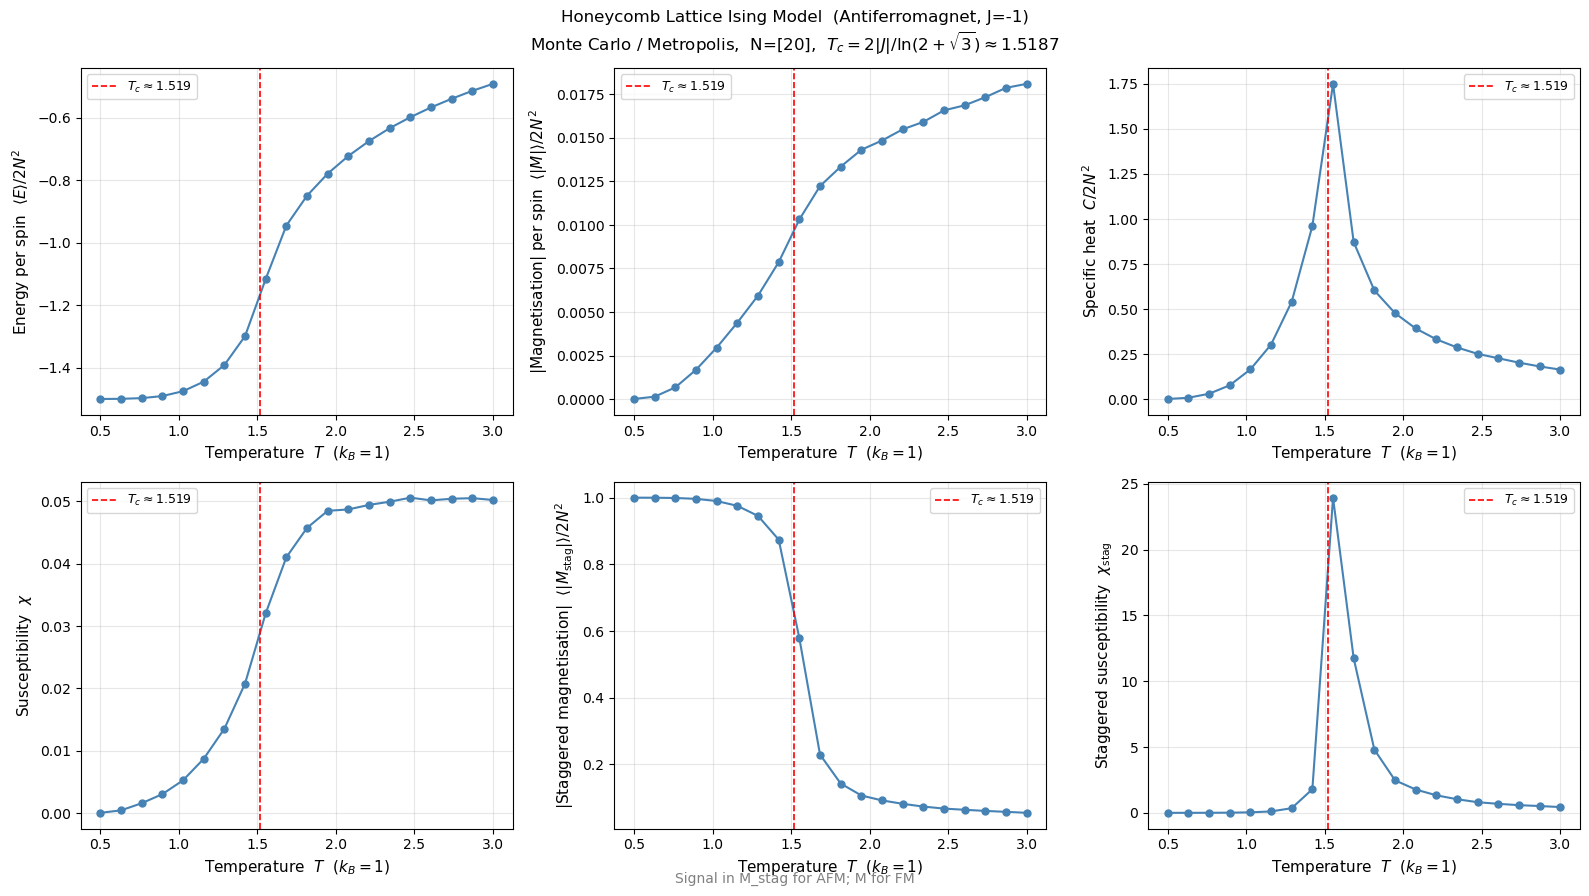

In [ ]:
#----------------------------------------------------------------------
##  PLOT THERMODYNAMIC OBSERVABLES
#----------------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    f'Honeycomb Lattice Ising Model  ({"Ferromagnet" if J > 0 else "Antiferromagnet"}, J={J})\n'
    f'Monte Carlo / Metropolis,  N={N_vals},  $T_c = 2|J|/\\ln(2+\\sqrt{{3}}) \\approx {T_c_exact:.4f}$',
    fontsize=12
)

plot_items = [
    (axes[0, 0], E,      r'Energy per spin  $\langle E \rangle / 2N^2$'),
    (axes[0, 1], M,      r'|Magnetisation| per spin  $\langle|M|\rangle / 2N^2$'),
    (axes[0, 2], C,      r'Specific heat  $C / 2N^2$'),
    (axes[1, 0], X,      r'Susceptibility  $\chi$'),
    (axes[1, 1], M_stag, r'|Staggered magnetisation|  $\langle|M_{\rm stag}|\rangle / 2N^2$'),
    (axes[1, 2], X_stag, r'Staggered susceptibility  $\chi_{\rm stag}$'),
]

for ax, obs, ylabel in plot_items:
    ax.plot(T, obs, 'o-', ms=5, color='steelblue')
    ax.axvline(T_c_exact, color='red', linestyle='--', linewidth=1.2,
               label=rf'$T_c \approx {T_c_exact:.3f}$')
    ax.set_xlabel(r'Temperature  $T$  ($k_B = 1$)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Annotation: for the ferromagnet, staggered quantities carry no signal
# (the staggered susceptibility will just be noisy near 0).
# For the antiferromagnet, M and X are the "wrong" order parameter; use M_stag.
note = 'Signal in M_stag for AFM; M for FM' if J < 0 else 'M_stag ~ 0 for FM (no Neel order)'
fig.text(0.5, 0.01, note, ha='center', fontsize=10, color='gray')

plt.tight_layout()
fig_dir = 'figures/' + type_folder
os.makedirs(fig_dir, exist_ok=True)
plt.savefig(fig_dir + '/observables.png', dpi=150)
plt.show()


--- T = 0.7632 ---


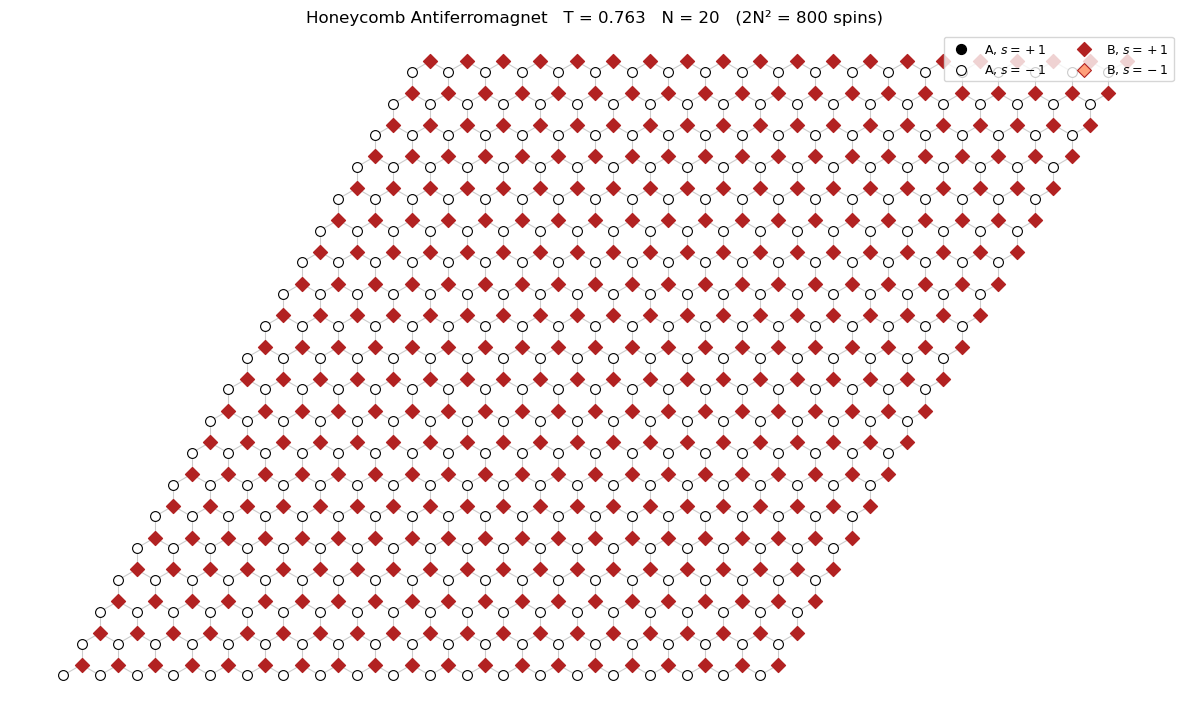


--- T = 1.5526 ---


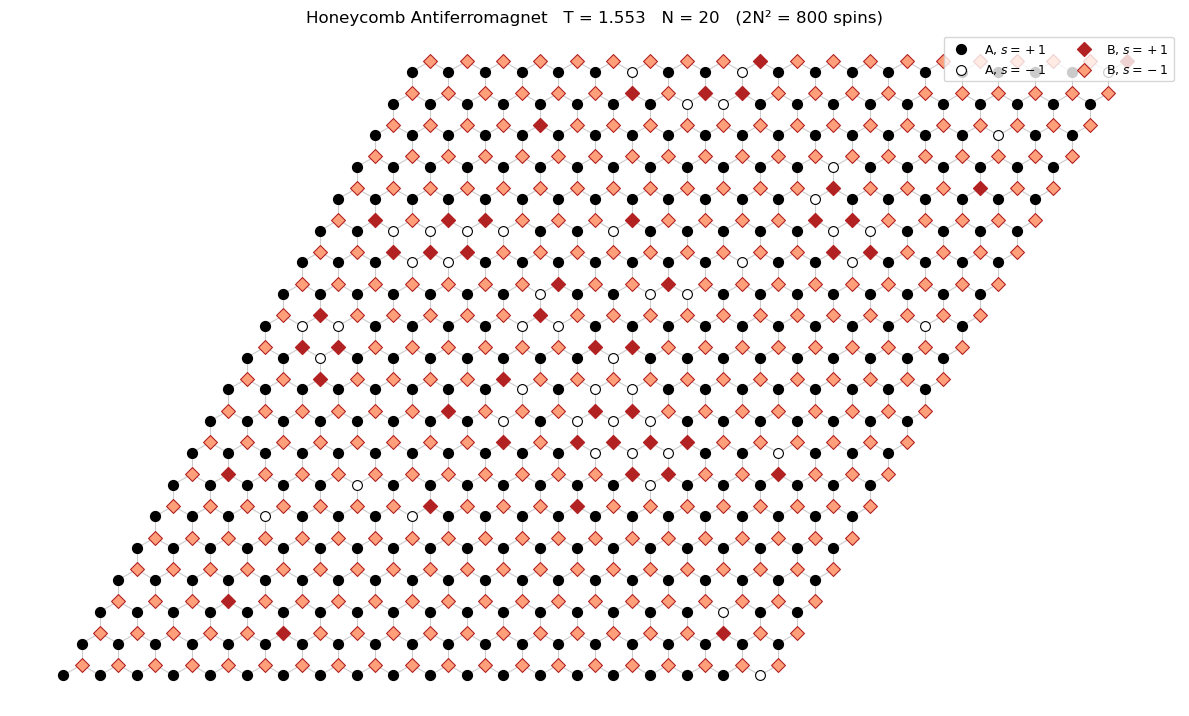


--- T = 2.4737 ---


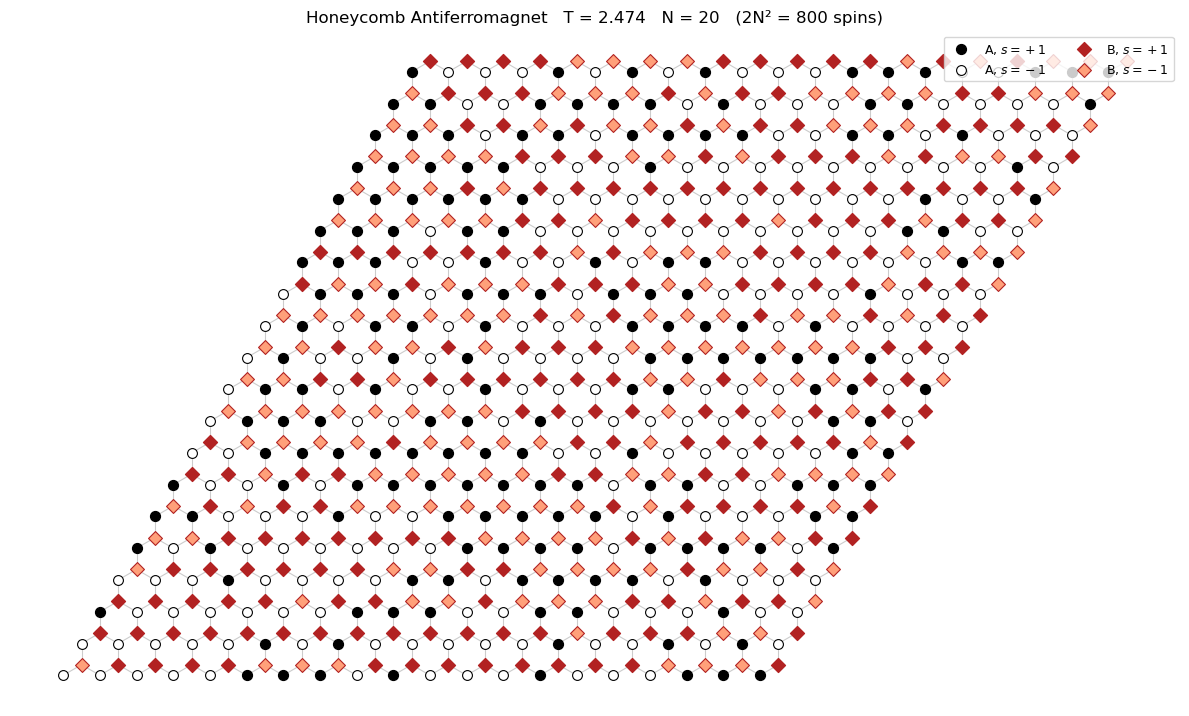

In [ ]:
#----------------------------------------------------------------------
##  VISUALIZE SPIN CONFIGURATIONS AT THREE TEMPERATURES
#----------------------------------------------------------------------

N_vis  = N_vals[0]
T_show = [T_c_exact * 0.5, T_c_exact, T_c_exact * 1.6]

for T_target in T_show:
    tt       = np.argmin(np.abs(T - T_target))
    T_actual = T[tt]
    beta_t   = 1.0 / T_actual
    fname    = 'beta_' + str(beta_t) + '_'
    fpath    = type_folder + '/data_N_' + str(N_vis) + '/' + fname + '.txt'

    if os.path.isfile(fpath):
        flat   = np.loadtxt(fpath)
        config = flat.reshape(2, N_vis, N_vis).astype(np.int64)
        print(f'\n--- T = {T_actual:.4f} ---')
        plotHoneycomb(
            config, N_vis, T_actual,
            title='Honeycomb Ferromagnet' if J > 0 else 'Honeycomb Antiferromagnet',
            draw_bonds=(N_vis <= 20),   # skip bonds for large N to avoid clutter
            folder='figures/' + type_folder
        )
    else:
        print(f'Config for T={T_actual:.4f} not found — run main loop first.')

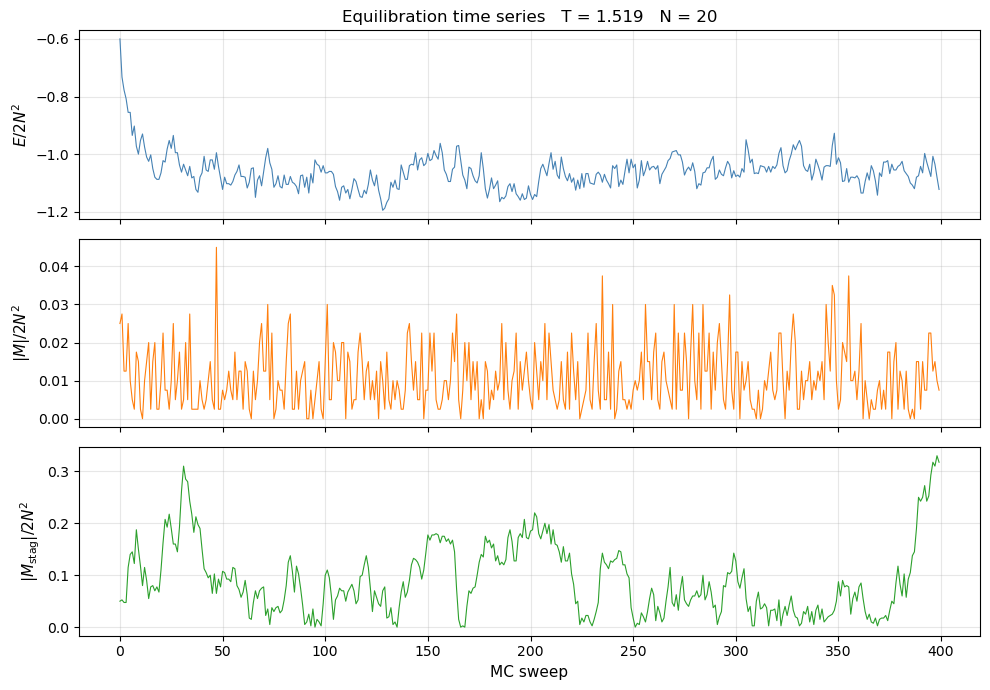

In [ ]:
#----------------------------------------------------------------------
##  EQUILIBRATION CHECK — time series near T_c
#----------------------------------------------------------------------

T_chk    = T_c_exact
N_chk    = N_vals[0]
beta_chk = 1.0 / T_chk
n_rec    = 400
Ns_chk   = 2 * N_chk * N_chk

config_chk = initialstate(N_chk)
E_ts    = np.zeros(n_rec)
M_ts    = np.zeros(n_rec)
Mst_ts  = np.zeros(n_rec)

for step in range(n_rec):
    config_chk = mcmove(config_chk, beta_chk, J, N_chk)
    E_ts[step]   = calcEnergy(config_chk, J, N_chk)  / Ns_chk
    M_ts[step]   = abs(calcMag(config_chk))          / Ns_chk
    Mst_ts[step] = abs(calcStagMag(config_chk))      / Ns_chk

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].plot(E_ts,   lw=0.8, color='steelblue');  axes[0].set_ylabel(r'$E/2N^2$', fontsize=11)
axes[1].plot(M_ts,   lw=0.8, color='C1');         axes[1].set_ylabel(r'$|M|/2N^2$', fontsize=11)
axes[2].plot(Mst_ts, lw=0.8, color='C2');         axes[2].set_ylabel(r'$|M_{\rm stag}|/2N^2$', fontsize=11)
axes[2].set_xlabel('MC sweep', fontsize=11)
axes[0].set_title(f'Equilibration time series   T = {T_chk:.3f}   N = {N_chk}', fontsize=12)
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/' + type_folder + '/equilibration.png', dpi=120)
plt.show()


FSS: N = 8  (2N² = 128 spins)


100%|██████████| 15/15 [00:01<00:00, 10.25it/s]



FSS: N = 16  (2N² = 512 spins)


100%|██████████| 15/15 [00:05<00:00,  2.85it/s]



FSS: N = 24  (2N² = 1152 spins)


100%|██████████| 15/15 [00:15<00:00,  1.02s/it]


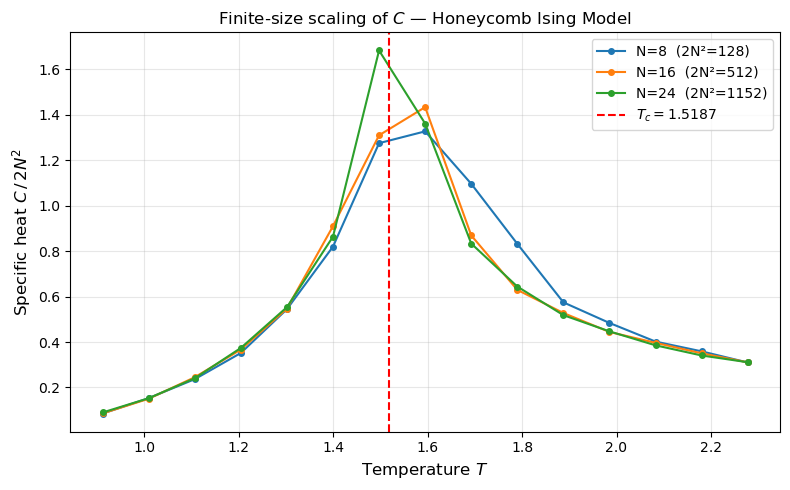

In [ ]:
#----------------------------------------------------------------------
##  FINITE-SIZE SCALING OF SPECIFIC HEAT
##  The C peak should sharpen and shift toward T_c as N increases.
#----------------------------------------------------------------------

N_fss   = [8, 16, 24]     # unit-cell sizes
nt_fss  = 15
eq_fss  = 5000
mc_fss  = 20000
T_fss   = np.linspace(T_c_exact * 0.6, T_c_exact * 1.5, nt_fss)
C_fss   = {}

for N in N_fss:
    C_N = np.zeros(nt_fss)
    Ns  = 2 * N * N
    print(f'\nFSS: N = {N}  (2N\u00b2 = {Ns} spins)')
    for tt in tqdm(range(nt_fss)):
        beta = 1.0 / T_fss[tt]
        cfg  = initialstate(N)
        for _ in range(eq_fss):
            cfg = mcmove(cfg, beta, J, N)
        E1 = E2 = 0
        n1_f = 1.0 / mc_fss
        n2_f = 1.0 / (mc_fss * mc_fss)
        for _ in range(mc_fss):
            cfg = mcmove(cfg, beta, J, N)
            Ene  = calcEnergy(cfg, J, N)
            E1  += Ene
            E2  += Ene * Ene
        C_N[tt] = (n1_f * E2 - n2_f * E1 * E1) * beta**2 / Ns
    C_fss[N] = C_N

plt.figure(figsize=(8, 5))
for N, C_N in C_fss.items():
    plt.plot(T_fss, C_N, 'o-', ms=4, label=f'N={N}  (2N\u00b2={2*N*N})')
plt.axvline(T_c_exact, color='red', linestyle='--',
            label=rf'$T_c = {T_c_exact:.4f}$')
plt.xlabel(r'Temperature $T$', fontsize=12)
plt.ylabel(r'Specific heat $C\,/\,2N^2$', fontsize=12)
plt.title('Finite-size scaling of $C$ — Honeycomb Ising Model', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/' + type_folder + '/finite_size_scaling.png', dpi=150)
plt.show()

Exact critical temperatures for the 2D Ising ferromagnet:
  Honeycomb  (z=3): T_c = 2J/ln(2+√3)  ≈ 1.5187
  Square     (z=4): T_c = 2J/ln(1+√2)  ≈ 2.2692
  Triangular (z=6): T_c = 4J/ln(3)     ≈ 3.6410

Mean-field prediction: T_c^MF = z*J = 3, 4, 6  (overestimates all three)


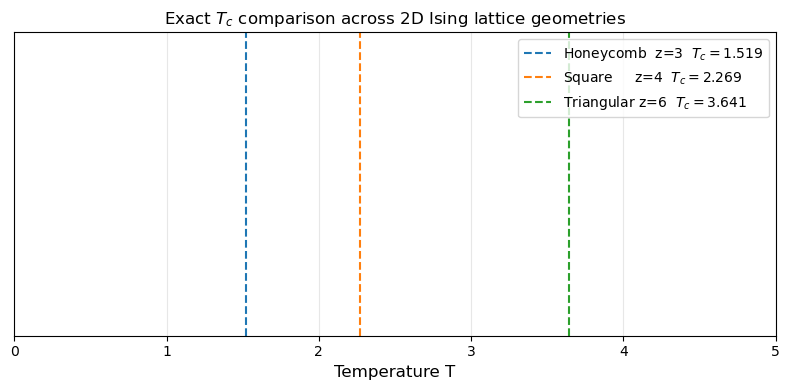

In [ ]:
#----------------------------------------------------------------------
##  COMPARE ALL THREE LATTICE GEOMETRIES
##  Load pre-computed E, M, C, X arrays from the other notebooks and
##  overlay them on a single figure.  Run this cell after completing
##  all three simulations (square, triangular, honeycomb).
#----------------------------------------------------------------------

# Exact critical temperatures for reference
Tc_sq  = 2.0 / np.log(1 + np.sqrt(2))     # ≈ 2.269  (square,      z=4)
Tc_tri = 4.0 / np.log(3)                   # ≈ 3.641  (triangular,  z=6)
Tc_hon = 2.0 / np.log(2 + np.sqrt(3))      # ≈ 1.519  (honeycomb,   z=3)

T_comp = np.linspace(0.3, 5.0, 30)

print('Exact critical temperatures for the 2D Ising ferromagnet:')
print(f'  Honeycomb  (z=3): T_c = 2J/ln(2+√3)  ≈ {Tc_hon:.4f}')
print(f'  Square     (z=4): T_c = 2J/ln(1+√2)  ≈ {Tc_sq:.4f}')
print(f'  Triangular (z=6): T_c = 4J/ln(3)     ≈ {Tc_tri:.4f}')
print()
print('Mean-field prediction: T_c^MF = z*J = 3, 4, 6  (overestimates all three)')

fig, ax = plt.subplots(figsize=(8, 4))
for Tc, label, color in [
    (Tc_hon, 'Honeycomb  z=3', 'C0'),
    (Tc_sq,  'Square     z=4', 'C1'),
    (Tc_tri, 'Triangular z=6', 'C2'),
]:
    ax.axvline(Tc, color=color, linestyle='--', label=f'{label}  $T_c={Tc:.3f}$')
ax.set_xlabel('Temperature T', fontsize=12)
ax.set_title('Exact $T_c$ comparison across 2D Ising lattice geometries', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(0, 5)
ax.set_yticks([])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/' + type_folder + '/Tc_comparison.png', dpi=120)
plt.show()